In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
df = pd.read_csv('../data/original/customer_churn_dataset-training-master.csv')
df_copy = df.copy()
df_copy.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [158]:
df_copy.drop(columns=['CustomerID'], inplace=True)
df_copy.columns = [col.lower().replace(' ', '_') for col in df_copy.columns] 

In [182]:
df_copy

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,30,Female,39,14,5,18,Standard,Annual,932.00,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.00,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.00,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.00,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.00,20,1
...,...,...,...,...,...,...,...,...,...,...,...
440828,42,Male,54,15,1,3,Premium,Annual,716.38,8,0
440829,25,Female,8,13,1,20,Premium,Annual,745.38,2,0
440830,26,Male,35,27,1,5,Standard,Quarterly,977.31,9,0
440831,28,Male,55,14,2,0,Standard,Quarterly,602.55,2,0


In [159]:
df_copy.describe()

,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [160]:
df_copy.isnull().sum()

age                  1
gender               1
tenure               1
usage_frequency      1
support_calls        1
payment_delay        1
subscription_type    1
contract_length      1
total_spend          1
last_interaction     1
churn                1
dtype: int64

In [161]:
df_copy[df_copy.isna().any(axis=1)]

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [162]:
df_copy.dropna(inplace=True)

In [163]:
descrete_col = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']
for col in descrete_col:
    df_copy[col] = df_copy[col].astype(int)

df_copy

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,30,Female,39,14,5,18,Standard,Annual,932.00,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.00,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.00,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.00,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.00,20,1
...,...,...,...,...,...,...,...,...,...,...,...
440828,42,Male,54,15,1,3,Premium,Annual,716.38,8,0
440829,25,Female,8,13,1,20,Premium,Annual,745.38,2,0
440830,26,Male,35,27,1,5,Standard,Quarterly,977.31,9,0
440831,28,Male,55,14,2,0,Standard,Quarterly,602.55,2,0


In [164]:
def make_histogram(df, target_feature, bins = 10, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    plt.hist(df[target_feature], bins=bins)
    if custom_ticks is not None:
        plt.xticks(custom_ticks)
    plt.ylabel('Count')
    plt.xlabel(target_feature)
    plt.title(f"Distribution of {target_feature.lower()}{additional}:\n")
    plt.grid()
    plt.show()
    print(f"Distribution of {target_feature.lower()}{additional}: {df[target_feature].mean():.2f} ± {df[target_feature].median():.2f} {unit}\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n{df[target_feature].skew():.3f} Skewness\n")

def make_piechart(df, target_feature, additional=''):
    dict_of_val_counts = dict(df[target_feature].value_counts())
    data = list(dict_of_val_counts.values())
    keys = list(dict_of_val_counts.keys())
    
    palette_color = sns.color_palette('bright')
    plt.pie(data, labels=keys, colors=palette_color, autopct='%.0f%%')
    plt.title(f"Distribution of Cutomer's {target_feature}:")
    plt.show()
    print_str = f"Distribution of cutomer's {target_feature.lower()}{additional}:"
    for k, v in zip(keys, data):
        print_str += f"\n{v} {k}"
    print(print_str)

def make_barplot(df, target_feature, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    dict_of_val_counts = dict(df[target_feature].value_counts())
    data = list(dict_of_val_counts.values())
    keys = list(dict_of_val_counts.keys())
    plt.bar(keys, data)
    if custom_ticks is not None:
        plt.xticks(custom_ticks)
    plt.xlabel(f'{target_feature.capitalize()}{additional}')
    plt.ylabel('Frequency')
    plt.title(f"Distribution of cutomer's {target_feature.lower()}{additional}\n")
    plt.grid(axis='y')
    plt.show()
    print(f"Distribution of cutomer's {target_feature.lower()}{additional}: {df[target_feature].mean():.2f} ± {df[target_feature].median():.2f} {unit}\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n\n{df[target_feature].skew():.3f} Skewness\n")
    
def make_boxplot(df, feature):
    plt.figure(figsize=(10,5))
    sns.boxplot(df, x=feature)
    plt.title(f"Boxplot of {feature}\n")
    plt.xlabel(feature)
    plt.ylabel("Values")
    plt.show()

## Discrete Data

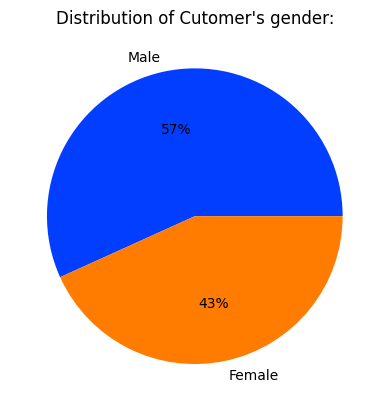

Distribution of cutomer's gender:
250252 Male
190580 Female


In [165]:
make_piechart(df_copy, "gender")

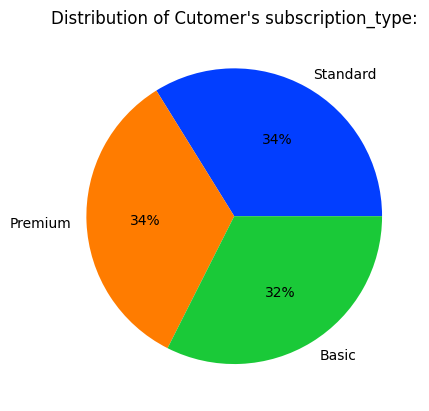

Distribution of cutomer's subscription_type:
149128 Standard
148678 Premium
143026 Basic


In [166]:
make_piechart(df_copy, 'subscription_type')

`There is a close balance of customers among the three subscription types: Standard, Premium, and Basic.`

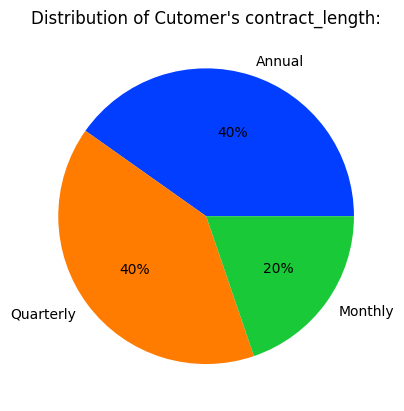

Distribution of cutomer's contract_length:
177198 Annual
176530 Quarterly
87104 Monthly


In [167]:
make_piechart(df_copy, 'contract_length')

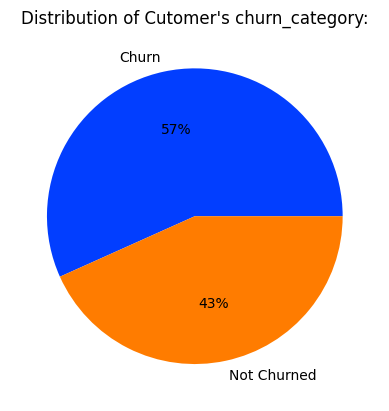

Distribution of cutomer's churn_category:
249999 Churn
190833 Not Churned


In [168]:
filtered = df_copy.copy()
filtered['churn_category'] = ['Churn' if x == 1.0 else 'Not Churned' for x in df_copy['churn']]
make_piechart(filtered, 'churn_category')

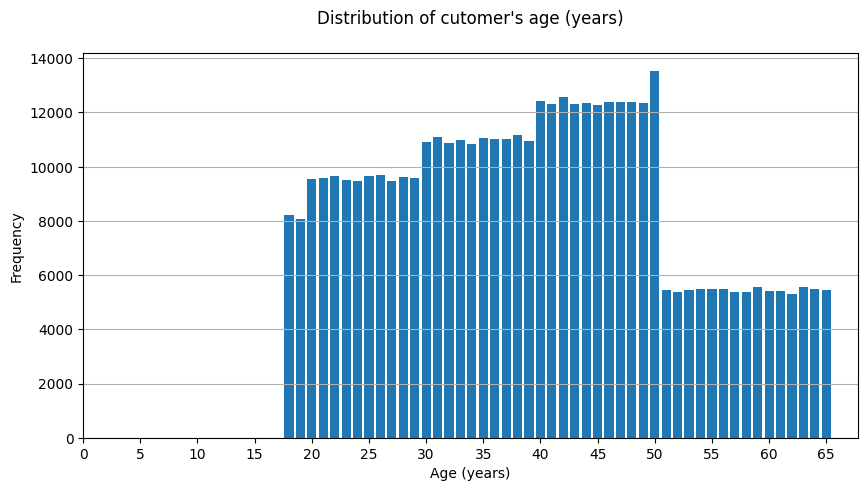

Distribution of cutomer's age (years): 39.37 ± 39.00 years
Median: 39.00 years
Minimum: 18 years
Maximum: 65 years

0.162 Skewness



In [169]:
make_barplot(df_copy, 'age', custom_ticks=np.arange(0, 66, 5), additional=' (years)', unit='years')

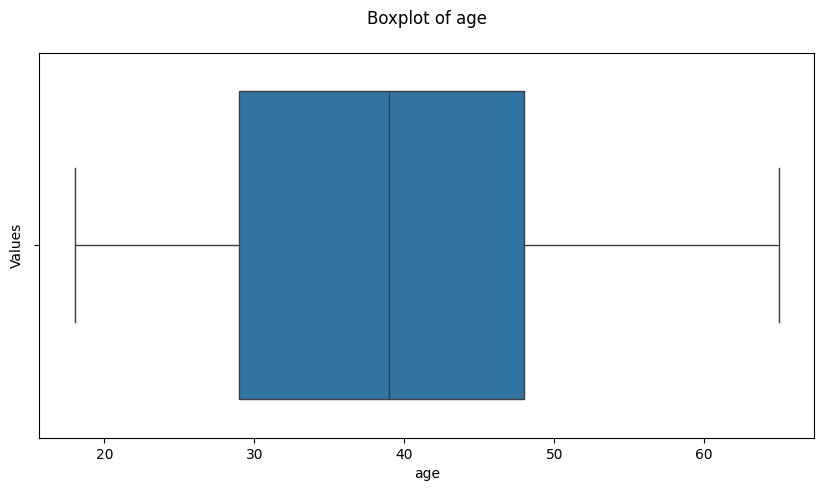

In [170]:
make_boxplot(df_copy, 'age')

`Most customers are aged 40-50 with age 50 being the most common. There's very low number of customers of age 51 and above.`

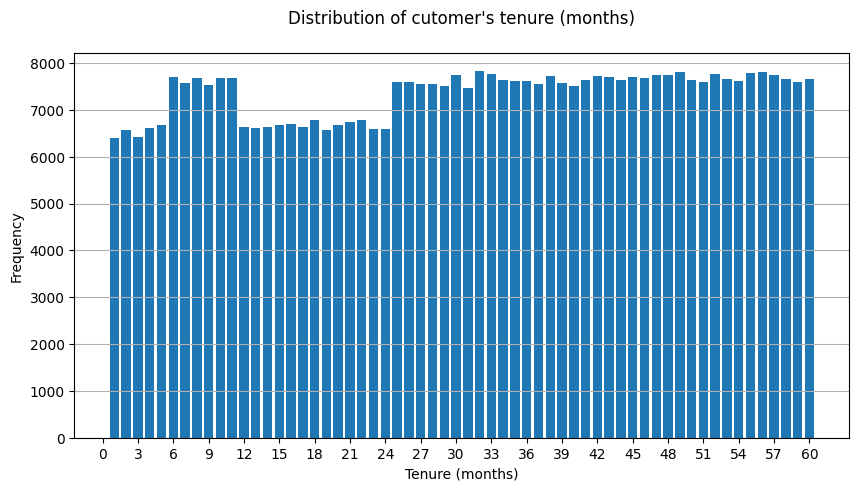

Distribution of cutomer's tenure (months): 31.26 ± 32.00 months
Median: 32.00 months
Minimum: 1 months
Maximum: 60 months

-0.061 Skewness



In [171]:
make_barplot(df_copy, 'tenure', custom_ticks=np.arange(0, 61, 3), additional=' (months)', unit='months')

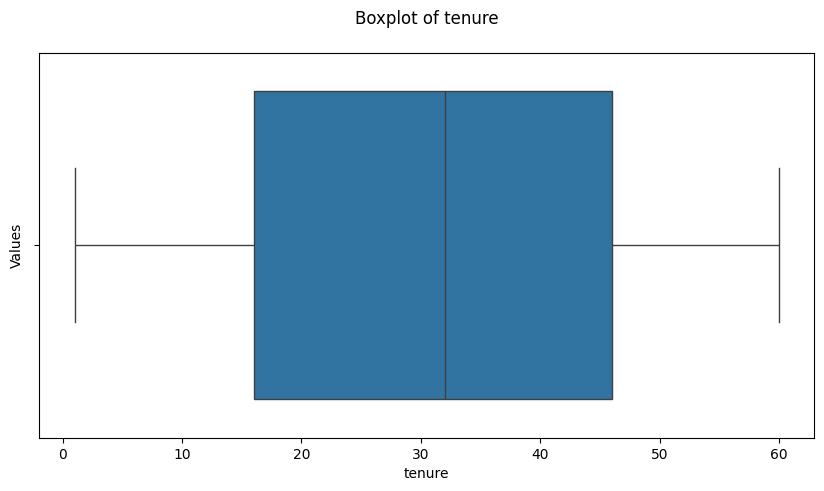

In [172]:
make_boxplot(df_copy, 'tenure')

`Customers tend to have longer tenures with customer departures being more common during the 1-5 month and 12-24 month tenure periods`

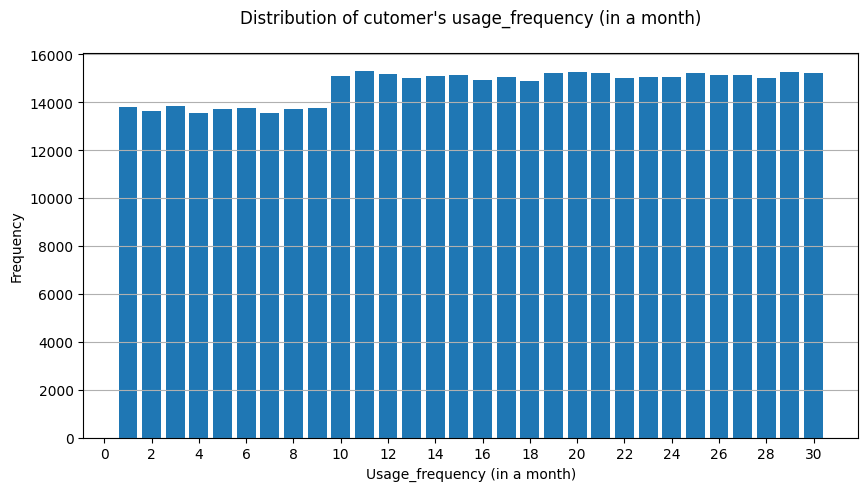

Distribution of cutomer's usage_frequency (in a month): 15.81 ± 16.00 times
Median: 16.00 times
Minimum: 1 times
Maximum: 30 times

-0.043 Skewness



In [173]:
make_barplot(df_copy, 'usage_frequency', custom_ticks=np.arange(0, 31, 2), unit='times', additional=' (in a month)')

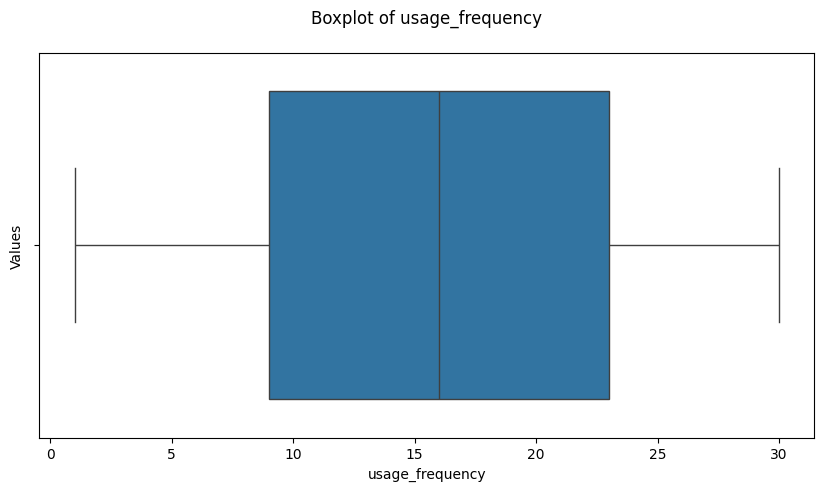

In [174]:
make_boxplot(df_copy, 'usage_frequency')

`On average, customers tend to use company's services 16 times in a month, with a large variability in individual usage frequency suggesting diverse service consumption habits.`

## Continuous Data

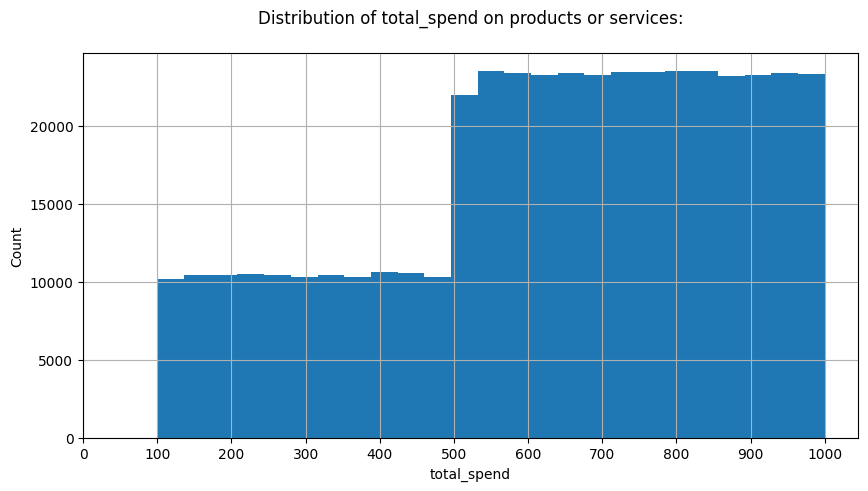

Distribution of total_spend on products or services: 631.62 ± 661.00 USD
Median: 661.00 USD
Minimum: 100.0 USD
Maximum: 1000.0 USD
-0.457 Skewness



In [175]:
make_histogram(df_copy, 'total_spend', bins=25, custom_ticks=np.arange(0, 1001, 100), unit='USD', additional=" on products or services")

## Bivariate Analysis

**Do gender and churn rate have any relationship?**

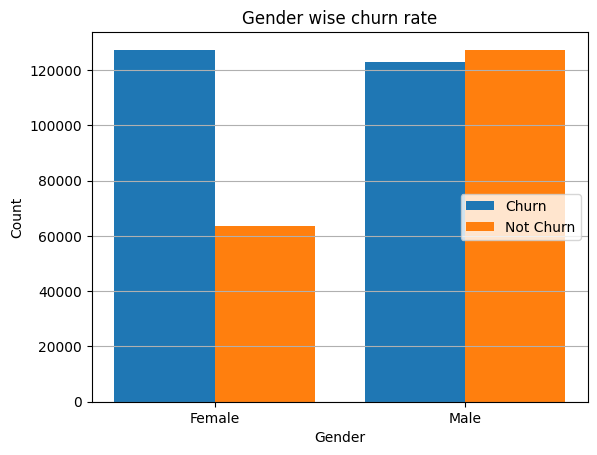

In [176]:
gender_churn = df_copy.groupby(['gender', 'churn']).size().unstack()

X = list(gender_churn.index)
churn_0 = list(gender_churn.iloc[:, 0])
churn_1 = list(gender_churn.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title("Gender wise churn rate")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

`Female customers exhibit a slightly higher churn rate compared to male customers. Active male customers (non-churned) is nearly double that of female customers.`

**What is the distribution of usage frequency for churned vs. non-churned customers?**

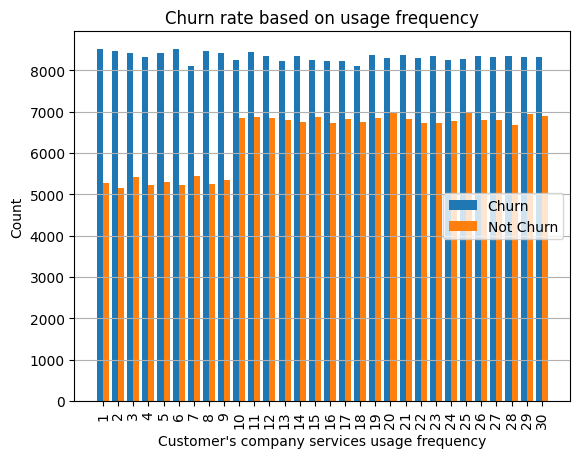

In [179]:
filtered = df_copy.groupby(['usage_frequency', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer's company services usage frequency")
plt.ylabel('Count')
plt.title("Churn rate based on usage frequency")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

`Churned customer tend to use company's services significantly more than customers who are not churned.`

**Are customers with longer tenures less likely to churn?**

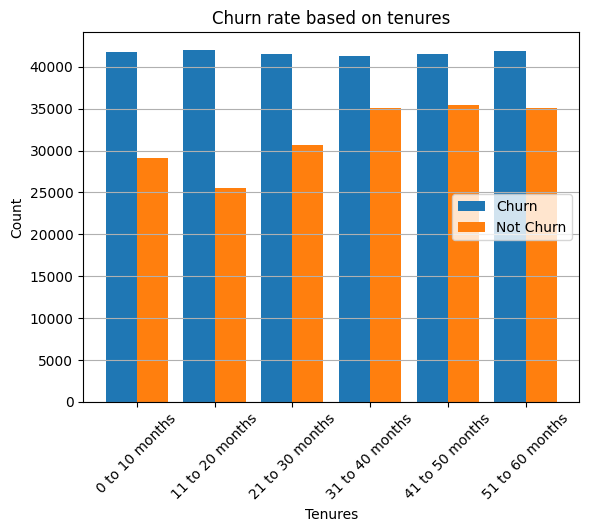

In [180]:
def categorize_age(age):
    if 0 <= age <= 10:
        return '0 to 10 months'
    elif 11 <= age <= 20:
        return '11 to 20 months'
    elif 21 <= age <= 30:
        return '21 to 30 months'
    elif 31 <= age <= 40:
        return '31 to 40 months'
    elif 41 <= age <= 50:
        return '41 to 50 months'
    elif 51 <= age <= 60:
        return '51 to 60 months'
    else:
        pass # For nan values

filtered = df_copy.copy()
filtered['tenure_segmentation'] = df_copy['tenure'].apply(categorize_age)
filtered = filtered.groupby(['tenure_segmentation', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Tenures')
plt.ylabel('Count')
plt.title("Churn rate based on tenures")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

`Customers with longer tenures are more likely to churn.`

**Do customers with more support calls tend to churn more?**

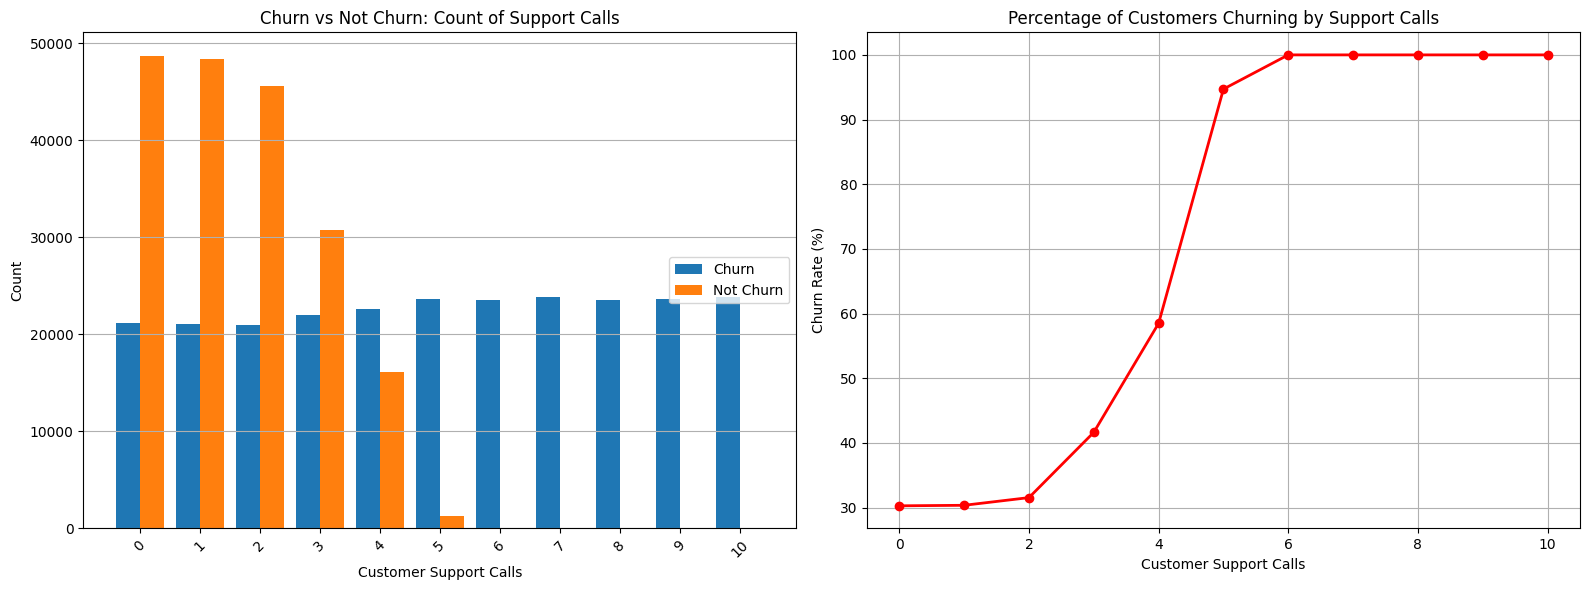

In [185]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

filtered = df_copy.groupby(['support_calls', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0].fillna(0)) 
churn_1 = list(filtered.iloc[:, 1].fillna(0))
  
X_axis = np.arange(len(X))
  
axs[0].bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
axs[0].bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
axs[0].set_xticks(X_axis)
axs[0].set_xticklabels(X, rotation=45)
axs[0].set_xlabel('Customer Support Calls')
axs[0].set_ylabel('Count')
axs[0].set_title('Churn vs Not Churn: Count of Support Calls')
axs[0].legend(loc='center right')
axs[0].grid(axis='y')

churn_rate_by_calls = df_copy.groupby('support_calls')['churn'].mean() * 100

axs[1].plot(churn_rate_by_calls.index, churn_rate_by_calls.values, marker='o', color='red', linewidth=2)

axs[1].set_xlabel('Customer Support Calls')
axs[1].set_ylabel('Churn Rate (%)')
axs[1].set_title('Percentage of Customers Churning by Support Calls')
axs[1].grid()

plt.tight_layout()

plt.show()


`Customers with more support calls tend to churn more.`

`On the contrary, customers who are not churned tend to make much more 0 to 3 customer support calls than churned customers, after which churned customers make significantly more calls.`